# 1章 入門チュートリアル

## データをその場で変更する

### データの読み込み

In [1]:
import numpy as np

import mne

In [2]:
# サンプルデータの読み取り
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
# the preload flag loads the data into memory now
raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True)
raw.crop(tmax=10.0)  # raw.crop() always happens in-place

Opening raw data file /Users/r.shimbo/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


/Users/r.shimbo/Desktop/MNE Python/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Raw | sample_audvis_raw.fif, 376 x 6007 (10.0 s), ~20.4 MiB, data loaded>

### 信号処理

In [ ]:
# プログラム1
original_raw = raw.copy()
raw.apply_hilbert()
print(
    f"original data type was {original_raw.get_data().dtype}, after "
    f"apply_hilbert the data type changed to {raw.get_data().dtype}."
)

original data type was float64, after apply_hilbert the data type changed to complex128.


### チャンネル選択

In [4]:
# プログラム2
print(f"original data had {original_raw.info['nchan']} channels.")
original_raw.pick("eeg")  # selects only the EEG channels
print(f"after picking, it has {original_raw.info['nchan']} channels.")

original data had 376 channels.
after picking, it has 60 channels.


### コピーパラメータ

EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Using matplotlib as 2D backend.


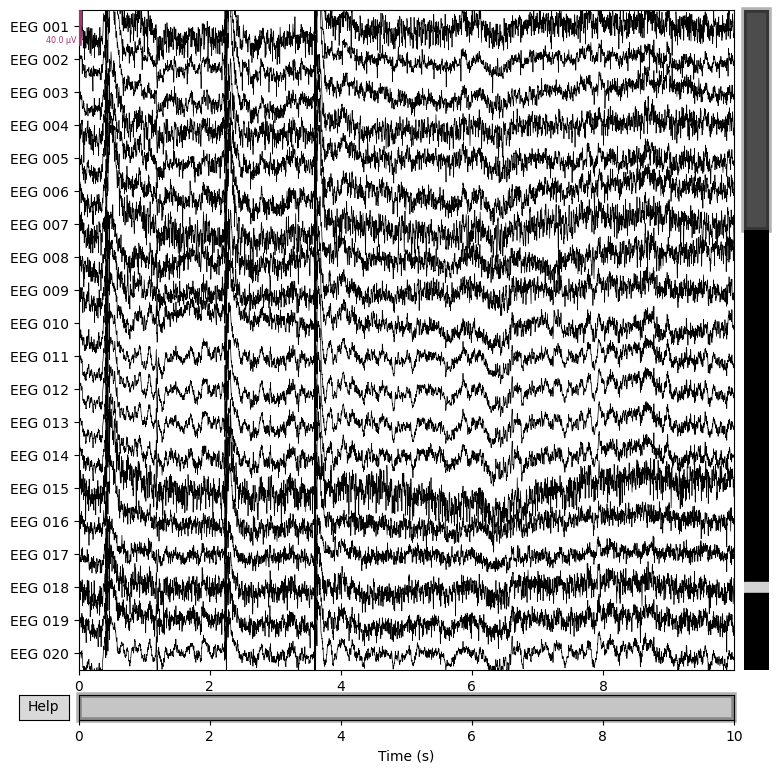

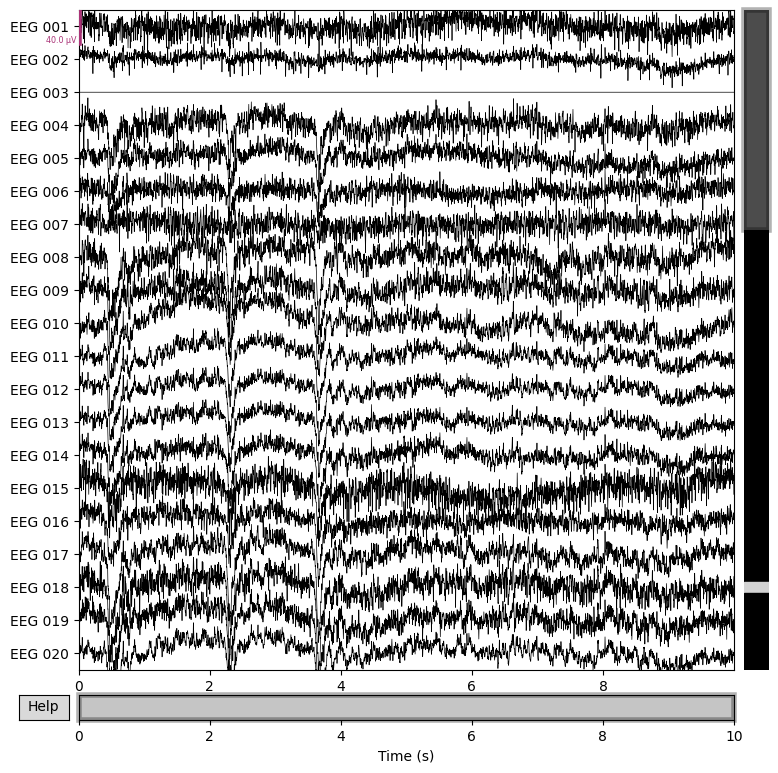

In [5]:
rereferenced_raw, ref_data = mne.set_eeg_reference(original_raw, ["EEG 003"], copy=True)
fig_orig = original_raw.plot()
fig_reref = rereferenced_raw.plot()